### 1. Import

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
sns.set()
import yfinance as yf
from datetime import timedelta
from IPython.display import display, HTML


### 2. 글로벌 외환 데이터 다운로드

In [11]:
# N개 통화에 대한 N-1개 환율 데이터의 야후 파이낸스 티커 정의
fx_tickers = ['EURUSD=X', 'GBPUSD=X', 'AUDUSD=X', 'USDJPY=X', 'USDKRW=X', 'USDCNY=X']

# FX 환율 데이터 다운로드 : 예시 기간 -> 2020~현재, 분석 기준 : 종가
fx_raw_data = yf.download(fx_tickers, start='2020-01-01', auto_adjust=False,)['Close']

# 날짜 인덱스 및 칼럼 정리
fx_raw_data.index = pd.to_datetime(fx_raw_data.index)
fx_raw_data.sort_index(inplace=True)
fx_raw_data.columns.name = None

# 데이터 확인
fx_raw_data.tail()


[*********************100%***********************]  6 of 6 completed


,AUDUSD=X,EURUSD=X,GBPUSD=X,USDCNY=X,USDJPY=X,USDKRW=X
Date,,,,,,
2026-09-21,0.712160,1.147974,1.338867,6.6975,157.046005,1384.859985
2026-09-22,0.711900,1.146460,1.337090,6.6953,157.369003,1373.680054
2026-09-23,0.711210,1.144794,1.334312,6.6996,157.464005,1350.359985
2026-09-24,0.703408,1.138187,1.324152,6.7111,158.264999,1362.500000
2026-09-25,0.703482,1.141032,1.325416,6.7037,NaN,1353.569946


### 3. 일 별 상대 통화 강도 데이터 생성

In [12]:
# 기준통화(달러) 대비 각 통화의 1일 변화율 계산 type 추출 
# 0 : 환율 역수의 변화율, 1 : 환율 자체의 변화율
fx_roc_type = {fx_ticker.replace('=X', '').replace('USD','') : [fx_ticker,[fx_ticker.replace('=X', '')[:3], fx_ticker.replace('=X', '')[3:]].index('USD')]for fx_ticker in fx_tickers}

# 일 별 상대 강도 측정을 위한 roc_type 별 데이터 변환
fx_roc_data = fx_raw_data.copy()

for currency, fx_ticker_type in fx_roc_type.items() :

    if fx_ticker_type[1] == 0 :
        fx_roc_data[fx_ticker_type[0]] = 1 / fx_roc_data[fx_ticker_type[0]]

    fx_roc_data.rename(columns = {fx_ticker_type[0] : currency}, inplace=True)

# 일 별 통화 강도 추출
fx_roc_data = fx_roc_data.pct_change().dropna()
fx_roc_data['USD'] = -fx_roc_data.mean(axis=1)

# 일 별 상대 통화 강도 Scoring 
# (최약 통화 : 1점 , 최강 통화 : 10점)
fx_roc_min = fx_roc_data.min(axis=1)
fx_roc_max = fx_roc_data.max(axis=1)

daily_fxr = fx_roc_data.sub(fx_roc_min, axis=0).div((fx_roc_max - fx_roc_min), axis=0)
daily_fxr = 1 + 9 * daily_fxr

# 일 별 상대 통화 강도 데이터 확인
daily_fxr.tail()


,AUD,EUR,GBP,CNY,JPY,KRW,USD
Date,,,,,,,
2026-09-21,8.408324,7.815298,10.000000,9.094958,1.000000,3.201926,8.332735
2026-09-22,2.490033,1.648293,1.640051,3.102789,1.000000,10.000000,2.311652
2026-09-23,1.515877,1.290157,1.000000,1.667890,1.685813,10.000000,1.072981
2026-09-24,1.000000,3.652366,2.712159,5.721888,4.014315,2.050945,10.000000
2026-09-25,3.105291,5.647137,4.006760,4.165536,2.993157,10.000000,1.000000


### 4. 최근 일자 환율 수준 확인

In [13]:
# 최근 일자 환율 데이터 프레임 함수
def create_recent_fx_df(fx_raw_data) :

    # 일별 데이터 별 환율 수준 데이터 프레임 분리코드
    recent_fx = {}

    for fx_col in fx_raw_data.columns.to_list() :

        # 환율 데이터 분리
        fx_raw = fx_raw_data[fx_col].dropna()

        # 현재 환율 수준 및 증감 추출
        fx_val = float(fx_raw.iloc[-1])
        fx_1b_val = float(fx_raw.iloc[-2])
        diff_val = fx_val - fx_1b_val

        # 현재 날짜 추출
        fx_recent_date = pd.to_datetime(fx_raw.index[-1]).strftime('%Y-%m-%d')

        # 증감 문자열 포맷팅 형식 지정
        if diff_val > 0:
            diff_str = f"(+{diff_val:.3f})"

        elif diff_val < 0:
            diff_str = f"({diff_val:.3f})"

        else:
            diff_str = "(0.00)"

        # 환율 수준 및 증감 문자열 포맷팅
        formatted_val = f"{fx_val:.2f} {diff_str}"

        # 일별 환율 수준 및 증감 데이터 프레임 생성 및 저장
        recent_fx[fx_col] = pd.DataFrame(
            {
                'Date' : fx_recent_date,
                'Value(C)' : formatted_val
            },
            index=[fx_col]
        )

    return recent_fx


# 최근 일자 외환 데이터 추출
recent_fx = create_recent_fx_df(fx_raw_data)

# 최근 일자 외환 데이터 출력
recent_fx_df = pd.concat(recent_fx.values(), axis=0)
recent_fx_df.index = [f"{ticker.replace('=X', '')[:3]}/{ticker.replace('=X', '')[3:]}" for ticker in recent_fx.keys()]

recent_fx_df


,Date,Value(C)
AUD/USD,2026-09-25,0.70 (+0.000)
EUR/USD,2026-09-25,1.14 (+0.003)
GBP/USD,2026-09-25,1.33 (+0.001)
USD/CNY,2026-09-25,6.70 (-0.007)
USD/JPY,2026-09-24,158.26 (+0.801)
USD/KRW,2026-09-25,1353.57 (-8.930)


### 5. 일 별 상대 통화 강도 분석

In [17]:
def render_currency_gauge_centered(selected_date, data_row):

    # CSS 설정 : 크기 확장 및 중앙 정렬
    gauge_style = f'''
    <style>
        .main-container {{
            background-color: #0E1117;
            padding: 30px;
            border-radius: 15px;
            font-family: 'Segoe UI', sans-serif;
            color: white;
            display: flex; /* 중앙 정렬을 위한 설정 */
            flex-direction: column;
            align-items: center; /* 가로축 중앙 */
            justify-content: center;
        }}

        .header-title {{
            font-size: 1.8rem; /* 제목 크기 키움 */
            font-weight: bold;
            margin-bottom: 35px;
            display: flex;
            align-items: center;
            gap: 12px;
        }}

        .gauge-wrapper {{
            display: flex;
            gap: 25px; /* 통화 간 간격 넓힘 */
            justify-content: center;
        }}

        .gauge-unit {{
            display: flex;
            flex-direction: column-reverse;
            align-items: center;
            gap: 6px;
        }}

        .bar {{
            width: 55px;  /* 막대 너비 키움 (기존 약 40px) */
            height: 18px; /* 막대 높이 키움 (기존 약 13px) */
            border-radius: 2px;
        }}

        .bar-on {{
            background-color: #7FFF00;
            box-shadow: 0 0 15px rgba(127, 255, 0, 0.8); /* 네온 효과 강화 */
        }}

        .bar-off {{
            background-color: #262730;
        }}

        .ticker-label {{
            color: #ffffff;
            font-weight: bold;
            margin-bottom: 15px;
            font-size: 16px; /* 티커 폰트 크기 키움 */
        }}
    </style>
    '''

    columns_content = ""

    for ticker, value in data_row.items():

        score = int(round(value))
        bars = "".join([
            f'<div class="bar {"bar-on" if i <= score else "bar-off"}"></div>'
            for i in range(1, 11)
        ])

        columns_content += f'''
        <div class="gauge-unit">
            <div class="ticker-label">{ticker}</div>
            {bars}
        </div>
        '''

    full_html = f'''
    <html>
        <body style="margin: 0; background-color: #0E1117;">
            {gauge_style}
            <div class="main-container">
                <div class="header-title">{selected_date} 상대 통화 강도</div>
                <div class="gauge-wrapper">
                    {columns_content}
                </div>
            </div>
        </body>
    </html>
    '''

    # 시각화
    display(HTML(full_html))


In [18]:
# 통화 강도 분석 대상 일자 선택하기
# None인 경우 가장 최근 거래일 사용
selected_date = '2026-08-31'

if selected_date is None :
    selected_date_str = daily_fxr.index[-1].strftime('%Y-%m-%d')

else :
    selected_date_str = pd.to_datetime(selected_date).strftime('%Y-%m-%d')

# 선택 일자 상대 통화 강도 시각화
try :

    target_row = daily_fxr.loc[selected_date_str]
    render_currency_gauge_centered(selected_date_str, target_row)

except KeyError :

    print(f"{selected_date_str} 데이터가 없습니다.")


### 6. 기간 별 누적 상대 통화 강도 분석

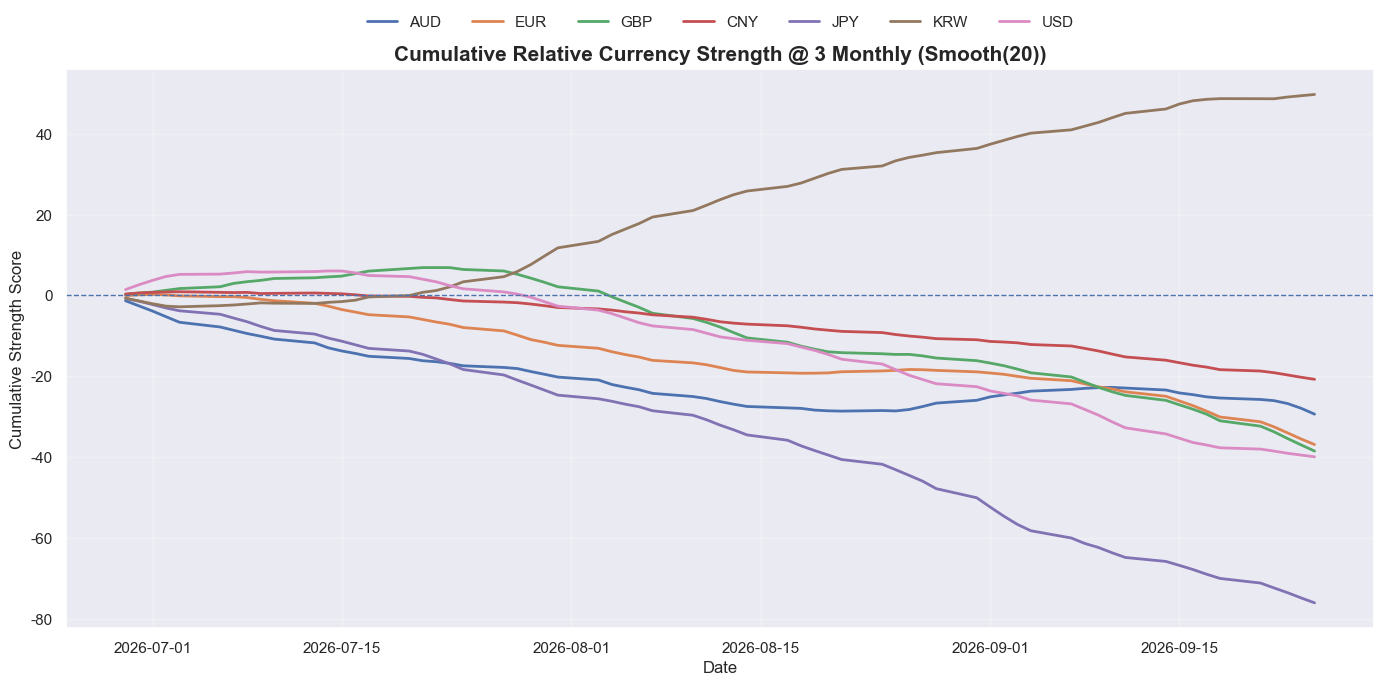

In [22]:
# 누적 상대 강도 탐색 기간 설정
selected_lookback_unit = 'Monthly'
selected_lookback = 3

# 시각화 옵션 선택
cum_rs_display_opt = 'Smooth(20)'   # 'Actual' 또는 'Smooth(20)'

# 선택 기간 지정
rs_end_date = daily_fxr.index[-1]

if selected_lookback_unit == 'Weekly' :

    rs_start_date = rs_end_date - timedelta(weeks=selected_lookback)

elif selected_lookback_unit == 'Monthly' :

    rs_start_date = rs_end_date - timedelta(days=selected_lookback * 30)

elif selected_lookback_unit == 'Yearly' :

    rs_start_date = rs_end_date - timedelta(days=selected_lookback * 365)

else :

    raise ValueError("selected_lookback_unit은 'Weekly', 'Monthly', 'Yearly' 중 하나여야 합니다.")


# Actaul 데이터 추출
actual_cum_rs_df = (daily_fxr.loc[rs_start_date:] - 5.5).cumsum()


# Smooth(20) 기간 선택 및 데이터 추출
actual_start_iloc = daily_fxr.index.get_loc(actual_cum_rs_df.index[0])
smooth_start_iloc = max(0, actual_start_iloc - 19)
smooth_start_loc_date = daily_fxr.iloc[smooth_start_iloc].name

smoothed_daily_rs_df = (
    (daily_fxr.loc[smooth_start_loc_date:] - 5.5)
    .rolling(20)
    .mean()
    .dropna()
)

smoothed_cum_rs_df = smoothed_daily_rs_df.loc[rs_start_date:].cumsum()


# 시각화 옵션 별 데이터 선택
if cum_rs_display_opt == 'Actual' :

    cumulative_rs_df = actual_cum_rs_df

elif cum_rs_display_opt == 'Smooth(20)' :

    cumulative_rs_df = smoothed_cum_rs_df

else :

    raise ValueError("cum_rs_display_opt은 'Actual', 'Smooth(20)' 중 하나여야 합니다.")


# 시각화
plt.figure(figsize=(14, 7))

for currency in cumulative_rs_df.columns :

    plt.plot(
        cumulative_rs_df.index,
        cumulative_rs_df[currency],
        linewidth=2,
        label=currency
    )

# 상대 강세 약세 기준선 표시 = 0
plt.axhline(0, linestyle='--', linewidth=1)
plt.title(
    f'Cumulative Relative Currency Strength @ '
    f'{selected_lookback} {selected_lookback_unit} ({cum_rs_display_opt})',
    fontsize=15,
    fontweight='bold'
)
plt.xlabel('Date')
plt.ylabel('Cumulative Strength Score')
plt.legend(
    ncol=len(cumulative_rs_df.columns),
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    frameon=False
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
